# Data generation — hrc_ur10_cell (Stage 2)

Turn the validated UR10 cell into a labelled dataset for the device-free worker
**presence / coarse count / safety-zone** task — now with optional **dynamic
clutter**.

For each snapshot: pick a human count (0 / 1 / 2), drop that many rigid
dielectric bodies at legal positions (biased toward the robot so the zone
classes balance); then — if clutter is on — drop **0–`MAX_AGV` mobile AGVs**
(metal boxes) at random legal positions (out of the red zone, clear of humans,
fixtures, and each other). Trace the CSI, background-subtract the empty cell,
and label (**humans only**):
- **presence** (0/1), **count** (0/1/2),
- **zone** = most-severe ISO/TS 15066 ring any worker occupies
  (0 none / 1 green / 2 yellow / 3 red).

**One notebook, two datasets** (`MAX_AGV` in the CONSTANTS cell):
- `MAX_AGV = 0` → reproduces the Scene 1 **anchor** (`hrc_ur10_cell_data_v0_robot.npz`).
- `MAX_AGV > 0` → the **dynamic-clutter** dataset (`hrc_ur10_dynamic_clutter_v0.npz`).

AGVs also perturb the channel, so the model must separate *human* from *machine*
— see the `datagen_spec_dynamic_clutter.md` for the full design. Reuses the
verified Stage-1 tracing pipeline (Sionna 2.0.1) and the geometry/TX/AP/zones
from `hrc_ur10_cell.json`.

**Run on Colab GPU.** Upload this notebook + the `hrc_ur10_cell/` folder (2 XMLs
+ JSON) into `/content`. The first cell installs Sionna + pins numpy and
auto-restarts once — then Run all. The AGV boxes come from Sionna's builtin box
mesh (no extra assets needed).

In [1]:
# ================================================================
# ENVIRONMENT + PACKAGES  (Colab: install Sionna + pin numpy, restart once)
# ================================================================
def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False
IN_COLAB = _in_colab()

NUMPY_PIN = '2.0.2'   # avoids the Colab numpy _blas_supports_fpe conflict
if IN_COLAB:
    import importlib.util, subprocess, sys, os
    need_restart = False
    if importlib.util.find_spec('sionna') is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'sionna==2.0.1'], check=True)
        need_restart = True
    import numpy as _np
    if _np.__version__ != NUMPY_PIN:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                        '--force-reinstall', f'numpy=={NUMPY_PIN}'], check=False)
        need_restart = True
    if need_restart:
        print(f'Installed Sionna + pinned numpy=={NUMPY_PIN}. RESTARTING -- then Run all again.')
        os.kill(os.getpid(), 9)
print('env ready | Colab:', IN_COLAB)

env ready | Colab: True


In [2]:
# ================================================================
# FILES + PATHS  (upload hrc_ur10_cell/ into /content on Colab)
# ================================================================
import os, json, math, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

if IN_COLAB:
    OUTPUT_DIR = Path('/content')
    # find hrc_ur10_cell.json wherever it was uploaded under /content
    hits = list(Path('/content').rglob('hrc_ur10_cell.json'))
    if not hits:
        raise FileNotFoundError(
            'hrc_ur10_cell.json not found under /content. Upload the 3 scene '
            'files (hrc_ur10_cell.json + the 2 XMLs). Current /content:\n '
            + '\n  '.join(sorted(p.name for p in Path('/content').iterdir())))
    SCENE_DIR = hits[0].parent
else:
    here = Path.cwd()
    cand = here / 'scenes' / 'hrc_ur10_cell'
    SCENE_DIR = cand if cand.exists() else here
    OUTPUT_DIR = here

cfg = json.loads((SCENE_DIR / 'hrc_ur10_cell.json').read_text(encoding='utf-8'))
VARIANT = 'robot'                       # 'robot' (main) or 'norobot' (coverage-ref dataset)
SCENE_XML = str(SCENE_DIR / cfg['variants'][VARIANT])
assert Path(SCENE_XML).exists(), f'{cfg["variants"][VARIANT]} missing next to the JSON in {SCENE_DIR}'
print('scene dir :', SCENE_DIR)
print('scene xml :', SCENE_XML)
print('out       :', OUTPUT_DIR)

scene dir : /content/hrc_ur10_cell
scene xml : /content/hrc_ur10_cell/hrc_ur10_cell_robot.xml
out       : /content


In [3]:
# --- imports (verified Stage-1 API) ---
import mitsuba as mi
import sionna.rt
from sionna.rt import (load_scene, PlanarArray, Transmitter, Receiver, Camera,
                       PathSolver, SceneObject, ITURadioMaterial,
                       subcarrier_frequencies)
print('sionna.rt', sionna.rt.__version__, '| mitsuba', mi.variant())

sionna.rt 2.0.1 | mitsuba cuda_ad_mono_polarized


In [ ]:
# ================================================================
# CONSTANTS  (edit N_SAMPLES / human + AGV settings here)
# ================================================================
FREQ_HZ         = 3.5e9
NUM_SUBCARRIERS = 64
K_TX, M_AP      = 4, 4

N_SAMPLES   = 50000      # 50k in ONE set; the model learning curve subsamples
                         # the train split down (16k / 8k / ...) so this covers
                         # every size. Set back to 8000 to reproduce the anchor.
MAX_WORKERS = 2          # human count classes: 0 / 1 / 2
RNG_SEED    = 0

# Human proxy: rigid dielectric sphere (~muscle tissue at 3.5 GHz),
# radius HUMAN_SCALE m, torso centre at HUMAN_Z (coarse -- refine to a cylinder later).
HUMAN_Z      = 1.0
HUMAN_SCALE  = 0.30
MIN_SEP      = 0.7       # min separation between two workers (m)
BIAS_P       = 0.55      # P(sample a worker near the robot) -> balances zones

# --- DYNAMIC CLUTTER (mobile AGVs) ---
#   MAX_AGV = 0  -> no clutter, reproduces the Scene 1 ANCHOR dataset.
#   MAX_AGV > 0  -> dynamic-clutter dataset: 0..MAX_AGV metal-box AGVs per
#                   snapshot at random legal positions (the confounder).
MAX_AGV            = 3
AGV_SIZE           = (1.0, 0.8, 0.4)   # metal box L x W x H (m)
AGV_Z              = 0.0                # base sits on the floor
AGV_MIN_SEP        = 1.4               # min centre distance between AGVs (m)
AGV_HUMAN_CLEAR    = 1.0               # min AGV-human centre distance (m)
AGV_ROBOT_STANDOFF = float(cfg['safety_zones']['red_radius'])  # AGVs stay OUT of red zone

# zones (from the sidecar) -- distance-from-robot rings
ZC   = cfg['safety_zones']['center']
REDR = cfg['safety_zones']['red_radius']
YELR = cfg['safety_zones']['yellow_radius']

# legal worker area (rect minus object footprints), from the sidecar
WR   = cfg['worker_region']
EXCL = WR['exclusions']
print(f'N={N_SAMPLES}, up to {MAX_WORKERS} workers, up to {MAX_AGV} AGVs '
      f'| zones red<={REDR} yellow<={YELR} m')

In [5]:
# --- load scene, arrays, TX/AP (from the sidecar) ---
scene = load_scene(SCENE_XML)
scene.frequency = FREQ_HZ

scene.tx_array = PlanarArray(num_rows=1, num_cols=1,
                             vertical_spacing=0.5, horizontal_spacing=0.5,
                             pattern='dipole', polarization='V')
scene.rx_array = PlanarArray(num_rows=1, num_cols=M_AP,
                             vertical_spacing=0.5, horizontal_spacing=0.5,
                             pattern='dipole', polarization='V')

for i, tx in enumerate(cfg['suggested_tx']):
    scene.add(Transmitter(name=f'iot_{i}', position=tx['pos'], display_radius=0.1))
scene.add(Receiver(name='ap', position=cfg['suggested_ap']['pos'], display_radius=0.1))
print('TXs:', list(scene.transmitters.keys()), '| RX:', list(scene.receivers.keys()))

TXs: ['iot_0', 'iot_1', 'iot_2', 'iot_3'] | RX: ['ap']


In [ ]:
# --- solver + tracer + bandwidth auto-tune (empty scene) ---
solver = PathSolver()
SOLVER_KW = dict(max_depth=5, los=True, specular_reflection=True,
                 diffuse_reflection=False, refraction=True,
                 synthetic_array=True, seed=41)

def _cfr(spacing):
    freqs = subcarrier_frequencies(NUM_SUBCARRIERS, spacing)
    paths = solver(scene=scene, **SOLVER_KW)
    h = paths.cfr(frequencies=freqs, normalize=True, normalize_delays=True, out_type='numpy')
    return np.nan_to_num(np.squeeze(h, axis=(0, 3, 4)).astype(np.complex64))  # -> [M_AP,K_TX,N]

# Sweep bandwidth on the EMPTY cell, auto-pick smallest reaching selectivity>=0.30.
CAND_MHZ = [20, 40, 60, 80, 100]; sel = {}
for bw in CAND_MHZ:
    h = _cfr(bw * 1e6 / NUM_SUBCARRIERS)
    m = np.abs(h)
    sel[bw] = float((m.std(-1) / (m.mean(-1) + 1e-12)).mean())
    print(f'{bw:4d} MHz -> freq-selectivity {sel[bw]:.3f}')
CHOSEN_MHZ = next((bw for bw in CAND_MHZ if sel[bw] >= 0.30), 80)
SUBCARRIER_SPACING = CHOSEN_MHZ * 1e6 / NUM_SUBCARRIERS
frequencies = subcarrier_frequencies(NUM_SUBCARRIERS, SUBCARRIER_SPACING)
print(f'CHOSEN bandwidth = {CHOSEN_MHZ} MHz (spacing {SUBCARRIER_SPACING/1e3:.1f} kHz)')

def trace_csi():
    """Trace once, then form the CFR TWO ways from the SAME set of paths:
      h_norm : normalize=True  -- energy-normalised channel (SHAPE only). What
               every run so far has used; the absolute received strength is
               divided out (average channel energy forced to 1).
      h_abs  : normalize=False -- absolute-GAIN channel. Keeps HOW STRONG the
               received signal is (path loss + reflectivity). A metal AGV is a
               strong reflector; a human body partly absorbs -> they change the
               absolute gain differently, so this is the extra axis for telling
               a machine apart from a person.
    Solving the paths is the expensive step (~250 ms); the second cfr() call is
    nearly free, so both channels come from IDENTICAL geometry -> a clean paired
    normalised-vs-gain comparison at the model stage, with no separate run."""
    paths = solver(scene=scene, **SOLVER_KW)
    def _fmt(h):
        return np.nan_to_num(np.squeeze(h, axis=(0, 3, 4)).astype(np.complex64))  # -> [M_AP,K_TX,N]
    h_norm = _fmt(paths.cfr(frequencies=frequencies, normalize=True,  normalize_delays=True, out_type='numpy'))
    h_abs  = _fmt(paths.cfr(frequencies=frequencies, normalize=False, normalize_delays=True, out_type='numpy'))
    return h_norm, h_abs

In [ ]:
# ================================================================
# add the worker bodies + AGV clutter (parked far outside until placed)
# ================================================================
# Human ~ muscle tissue at 3.5 GHz (eps_r~48, sigma~3). If the custom-material
# API differs on your build, fall back to an ITU dielectric.
try:
    from sionna.rt import RadioMaterial
    human_mat = RadioMaterial('human-mat', relative_permittivity=48.0, conductivity=3.0)
except Exception as e:
    print('custom RadioMaterial API differs -> ITU concrete fallback:', e)
    human_mat = ITURadioMaterial(name='human-mat', itu_type='concrete', thickness=0.3)

PARK = mi.Point3f(0.0, 0.0, -50.0)      # outside the sealed room -> no RF effect
humans = []
for w in range(MAX_WORKERS):
    obj = SceneObject(fname=sionna.rt.scene.sphere, name=f'human_{w}', radio_material=human_mat)
    scene.edit(add=obj)
    obj = scene.get(f'human_{w}')
    try:
        obj.scaling = HUMAN_SCALE
    except Exception as e:
        print('scaling API differs (non-fatal):', e)
    obj.position = PARK
    humans.append(obj)
print('workers added:', [f'human_{w}' in scene.objects for w in range(MAX_WORKERS)])

# AGV clutter = metal boxes. The builtin box mesh is 10x10x5 m with its base at
# z=0, so a per-axis scale of (L/10, W/10, H/5) gives an AGV_SIZE box on the floor.
agvs = []
if MAX_AGV > 0:
    agv_mat = ITURadioMaterial(name='agv-mat', itu_type='metal', thickness=0.1)
    box_ply = os.path.join(os.path.dirname(sionna.rt.scene.box), 'meshes', 'box.ply')
    agv_scale = mi.Point3f(AGV_SIZE[0] / 10.0, AGV_SIZE[1] / 10.0, AGV_SIZE[2] / 5.0)
    for k in range(MAX_AGV):
        obj = SceneObject(fname=box_ply, name=f'agv_{k}', radio_material=agv_mat)
        scene.edit(add=obj)
        obj = scene.get(f'agv_{k}')
        obj.scaling = agv_scale
        obj.position = PARK
        agvs.append(obj)
    print('AGVs added:', [f'agv_{k}' in scene.objects for k in range(MAX_AGV)],
          '| box ->', tuple(round(v, 2) for v in AGV_SIZE), 'm')

# Empty-cell reference = all humans AND AGVs parked (room + fixtures + UR10 only).
# Trace it BOTH ways too, so background subtraction is done consistently on the
# normalised channel AND on the absolute-gain channel.
for h in humans: h.position = PARK
for g in agvs:   g.position = PARK
csi_empty, csi_empty_abs = trace_csi()
print('csi_empty shape:', csi_empty.shape, '| empty abs mean|H|:',
      round(float(np.abs(csi_empty_abs).mean()), 5))

In [8]:
# ================================================================
# PRE-SAMPLE humans + AGVs + labels (deterministic -> resumable)
# ================================================================
rng = np.random.default_rng(RNG_SEED)

def in_region(x, y):
    if not (WR['x_min'] <= x <= WR['x_max'] and WR['y_min'] <= y <= WR['y_max']):
        return False
    for e in EXCL:
        if e['x_min'] <= x <= e['x_max'] and e['y_min'] <= y <= e['y_max']:
            return False
    return True

def zone_of(x, y):
    d = math.hypot(x - ZC[0], y - ZC[1])
    if d <= REDR: return 3          # red (stop)
    if d <= YELR: return 2          # yellow (reduced)
    return 1                        # green (full speed)

def sample_one(rng):                # biased human sampler (toward the robot)
    for _ in range(2000):
        if rng.random() < BIAS_P:
            r = YELR * 1.3 * math.sqrt(rng.random()); th = rng.uniform(0, 2*math.pi)
            x, y = ZC[0] + r*math.cos(th), ZC[1] + r*math.sin(th)
        else:
            x = rng.uniform(WR['x_min'], WR['x_max']); y = rng.uniform(WR['y_min'], WR['y_max'])
        if in_region(x, y):
            return x, y
    return None

_AGV_HX, _AGV_HY = AGV_SIZE[0]/2, AGV_SIZE[1]/2

def agv_ok(x, y, humans_xy, agvs_xy):
    axmin, axmax, aymin, aymax = x-_AGV_HX, x+_AGV_HX, y-_AGV_HY, y+_AGV_HY
    for e in EXCL:                                       # no overlap with fixed footprints
        if not (axmax < e['x_min'] or axmin > e['x_max'] or aymax < e['y_min'] or aymin > e['y_max']):
            return False
    if math.hypot(x - ZC[0], y - ZC[1]) < AGV_ROBOT_STANDOFF:        # stay out of the red zone
        return False
    if any(math.hypot(x-hx, y-hy) < AGV_HUMAN_CLEAR for hx, hy in humans_xy):
        return False
    if any(math.hypot(x-gx, y-gy) < AGV_MIN_SEP for gx, gy in agvs_xy):
        return False
    return True

def sample_agv(rng, humans_xy, agvs_xy):
    for _ in range(200):
        x = rng.uniform(WR['x_min']+_AGV_HX, WR['x_max']-_AGV_HX)
        y = rng.uniform(WR['y_min']+_AGV_HY, WR['y_max']-_AGV_HY)
        if agv_ok(x, y, humans_xy, agvs_xy):
            return x, y
    return None

counts    = rng.integers(0, MAX_WORKERS + 1, size=N_SAMPLES).astype(np.int8)
positions = np.full((N_SAMPLES, MAX_WORKERS, 2), np.nan, np.float32)
agv_counts    = np.zeros(N_SAMPLES, np.int8)
agv_positions = np.full((N_SAMPLES, max(MAX_AGV, 1), 2), np.nan, np.float32)
for i in range(N_SAMPLES):
    placed = []
    for _w in range(int(counts[i])):
        for _try in range(50):
            p = sample_one(rng)
            if p and all(math.hypot(p[0]-q[0], p[1]-q[1]) >= MIN_SEP for q in placed):
                placed.append(p); break
    counts[i] = len(placed)                           # in case a placement failed
    for w, (x, y) in enumerate(placed):
        positions[i, w] = (x, y)
    if MAX_AGV > 0:                                   # dynamic clutter: sample AGVs
        na = int(rng.integers(0, MAX_AGV + 1))
        gs = []
        for _ in range(na):
            p = sample_agv(rng, placed, gs)
            if p: gs.append(p)                        # else: fewer AGVs this snapshot
        agv_counts[i] = len(gs)
        for k, (x, y) in enumerate(gs):
            agv_positions[i, k] = (x, y)

presence = (counts > 0).astype(np.int8)
zone = np.zeros(N_SAMPLES, np.int8)                   # 0 = none (no worker)
for i in range(N_SAMPLES):
    zs = [zone_of(*positions[i, w]) for w in range(int(counts[i]))]
    zone[i] = max(zs) if zs else 0

def place_sample(i):
    """Position humans + AGVs for snapshot i; park the unused ones."""
    for w in range(MAX_WORKERS):
        humans[w].position = (mi.Point3f(float(positions[i, w, 0]), float(positions[i, w, 1]), HUMAN_Z)
                              if w < counts[i] else PARK)
    for k in range(MAX_AGV):
        agvs[k].position = (mi.Point3f(float(agv_positions[i, k, 0]), float(agv_positions[i, k, 1]), AGV_Z)
                            if k < agv_counts[i] else PARK)

print('count  balance:', np.bincount(counts, minlength=3).tolist())
print('zone   balance (none/green/yellow/red):', np.bincount(zone, minlength=4).tolist())
if MAX_AGV > 0:
    print('agv    balance:', np.bincount(agv_counts, minlength=MAX_AGV+1).tolist())
    print('false-alarm subset (0 human & >=1 AGV):', int(((counts == 0) & (agv_counts >= 1)).sum()))

count  balance: [2656, 2689, 2655]
zone   balance (none/green/yellow/red): [2656, 2993, 1366, 985]
agv    balance: [2006, 2018, 1968, 2008]
false-alarm subset (0 human & >=1 AGV): 1965


In [9]:
# --- timing calibration: project the full-sweep runtime before committing ---
N_CALIB = 20
_t = time.time()
for i in range(N_CALIB):
    place_sample(i)
    trace_csi()
per = (time.time() - _t) / N_CALIB
print(f'{per*1000:6.1f} ms / solve  ->  projected {per*N_SAMPLES/60:5.1f} min for N={N_SAMPLES:,}'
      f'  (MAX_AGV={MAX_AGV})')

 253.5 ms / solve  ->  projected  33.8 min for N=8,000  (MAX_AGV=3)


In [ ]:
# ================================================================
# SWEEP with checkpoint / resume  -> csi_raw (+ csi_raw_abs), then bg-subtract
# ================================================================
CKPT = os.path.join(OUTPUT_DIR, 'ur10_sweep_ckpt.npz')
CKPT_EVERY = 1000

if os.path.exists(CKPT):
    _z = np.load(CKPT)
    if 'csi_raw_abs' not in _z.files:
        raise RuntimeError(
            'Old checkpoint has no absolute-gain array. The gain cannot be '
            'recovered from a normalised-only run -> delete ur10_sweep_ckpt.npz '
            'and start the sweep fresh.')
    csi_raw = _z['csi_raw']; csi_raw_abs = _z['csi_raw_abs']; start = int(_z['done'])
    assert csi_raw.shape[0] == N_SAMPLES, 'checkpoint N mismatch -- delete ur10_sweep_ckpt.npz'
    print(f'resuming from {start:,}/{N_SAMPLES:,}')
else:
    csi_raw     = np.zeros((N_SAMPLES, M_AP, K_TX, NUM_SUBCARRIERS), np.complex64)
    csi_raw_abs = np.zeros((N_SAMPLES, M_AP, K_TX, NUM_SUBCARRIERS), np.complex64); start = 0
    print('starting fresh sweep')

_t0 = time.time()
for i in range(start, N_SAMPLES):
    place_sample(i)                                  # humans + AGVs (parks unused)
    csi_raw[i], csi_raw_abs[i] = trace_csi()         # normalised + absolute-gain
    if (i + 1) % CKPT_EVERY == 0 or (i + 1) == N_SAMPLES:
        np.savez(CKPT, csi_raw=csi_raw, csi_raw_abs=csi_raw_abs, done=i + 1)
        rate = (i + 1 - start) / (time.time() - _t0)
        print(f'  {i+1:>7,}/{N_SAMPLES:,}  ({rate:5.1f}/s, ETA {(N_SAMPLES-(i+1))/rate/60:5.1f} min)')

# Background subtraction on BOTH channels (empty cell = fixed room + fixtures):
#   csi_bgsub     -- normalised (SHAPE) perturbation, as used so far.
#   csi_bgsub_abs -- absolute additive scattered field the bodies introduced
#                    (physically consistent: same absolute scale as the empty ref,
#                    since both keep their true gain instead of being rescaled).
csi_bgsub     = (csi_raw     - csi_empty[None]).astype(np.complex64)
csi_bgsub_abs = (csi_raw_abs - csi_empty_abs[None]).astype(np.complex64)
print('csi_raw:', csi_raw.shape, '| csi_bgsub:', csi_bgsub.shape, '| NaNs:', int(np.isnan(csi_raw).sum()))
print('abs-gain check: mean|raw_abs| =', round(float(np.abs(csi_raw_abs).mean()), 5),
      '| normalised mean|raw| =', round(float(np.abs(csi_raw).mean()), 5),
      '(abs should be a physical scale, NOT ~1)')

In [11]:
# --- split: stratified random by count (single-scene feasibility) ---
# NOTE: this is the CORE result split (can the model sense in this cell?).
# The harder cross-position / cross-scene generalisation is the Stage-2
# STRETCH and uses a spatial / cross-scene split instead. Positions are
# stored, so we can re-split later without regenerating.
split = np.empty(N_SAMPLES, dtype=object)
rs = np.random.default_rng(RNG_SEED + 1)
for c in range(MAX_WORKERS + 1):
    idx = np.where(counts == c)[0]; rs.shuffle(idx)
    n_test = int(0.15 * len(idx)); n_val = int(0.15 * len(idx))
    split[idx[:n_test]] = 'test'
    split[idx[n_test:n_test + n_val]] = 'val'
    split[idx[n_test + n_val:]] = 'train'
for s in ['train', 'val', 'test']:
    print(f'{s:5s}: {int((split == s).sum())}')

train: 5602
val  : 1199
test : 1199


In [ ]:
# --- save dataset (filename keys off clutter mode + size; nothing is clobbered) ---
CLUTTER = MAX_AGV > 0
# size-tagged name (e.g. hrc_ur10_dynamic_clutter_50k.npz) so the 8k anchor
# (hrc_ur10_dynamic_clutter_v0.npz) and any other size all coexist. The file now
# ALSO carries the absolute-gain arrays (csi_*_abs) beside the normalised ones --
# a strict SUPERSET, so older notebooks that read csi_raw / csi_bgsub still work.
out_name = (f'hrc_ur10_dynamic_clutter_{N_SAMPLES//1000}k.npz' if CLUTTER
            else f'hrc_ur10_cell_data_v0_{VARIANT}.npz')
out = os.path.join(OUTPUT_DIR, out_name)
np.savez_compressed(
    out,
    csi_raw=csi_raw, csi_bgsub=csi_bgsub, csi_empty=csi_empty,
    csi_raw_abs=csi_raw_abs, csi_bgsub_abs=csi_bgsub_abs, csi_empty_abs=csi_empty_abs,
    count=counts, presence=presence, zone=zone, positions=positions,
    agv_count=agv_counts, agv_positions=agv_positions,
    split=split.astype(str),
    freq_hz=FREQ_HZ, num_subcarriers=NUM_SUBCARRIERS,
    subcarrier_spacing_hz=SUBCARRIER_SPACING, k_tx=K_TX, m_ap=M_AP,
    human_z=HUMAN_Z, human_scale=HUMAN_SCALE, variant=VARIANT,
    agv_size=np.array(AGV_SIZE, np.float32), agv_z=AGV_Z, max_agv=MAX_AGV,
    zone_center=np.array(ZC, np.float32), red_radius=REDR, yellow_radius=YELR,
    zone_labels=np.array(['none', 'green', 'yellow', 'red']))
print('saved', out, round(os.path.getsize(out) / 1e6, 2), 'MB | clutter:', CLUTTER)
print('arrays: csi_raw/bgsub/empty (normalised) + csi_raw_abs/bgsub_abs/empty_abs (absolute gain)')
if os.path.exists(CKPT):
    os.remove(CKPT); print('removed checkpoint')

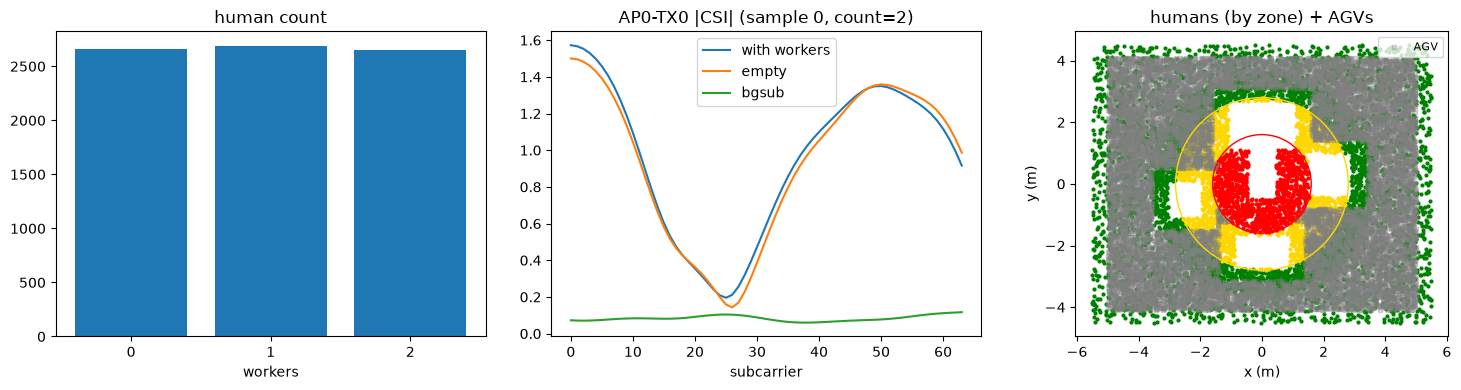

mean |bgsub| by (human_count x agv_count):
           agv0 agv1 agv2 agv3
  human 0: 0.000  0.011  0.021  0.031
  human 1: 0.040  0.047  0.056  0.058
  human 2: 0.069  0.074  0.079  0.085


In [13]:
# --- sanity: class balance, an example bgsub, positions + clutter, confound ---
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(['0', '1', '2'], np.bincount(counts, minlength=3)); ax[0].set_title('human count')
ax[0].set_xlabel('workers')

i = int(np.argmax(counts))     # a busy sample
ax[1].plot(np.abs(csi_raw[i, 0, 0]), label='with workers')
ax[1].plot(np.abs(csi_empty[0, 0]), label='empty')
ax[1].plot(np.abs(csi_bgsub[i, 0, 0]), label='bgsub')
ax[1].set_title(f'AP0-TX0 |CSI| (sample {i}, count={counts[i]})'); ax[1].legend(); ax[1].set_xlabel('subcarrier')

colz = {1: 'green', 2: 'gold', 3: 'red'}
for w in range(MAX_WORKERS):
    pxy = positions[:, w, :]; m = ~np.isnan(pxy[:, 0])
    zz = np.array([zone_of(*pxy[k]) for k in np.where(m)[0]])
    for zval, col in colz.items():
        sel = zz == zval
        ax[2].scatter(pxy[m][sel, 0], pxy[m][sel, 1], s=4, c=col)
if MAX_AGV > 0:                                   # AGV footprints (grey squares)
    apx = agv_positions[..., 0].ravel(); apy = agv_positions[..., 1].ravel(); am = ~np.isnan(apx)
    ax[2].scatter(apx[am], apy[am], s=8, c='gray', marker='s', alpha=0.3, label='AGV')
    ax[2].legend(loc='upper right', fontsize=8)
ax[2].add_patch(plt.Circle(ZC, REDR, fill=False, ec='red')); ax[2].add_patch(plt.Circle(ZC, YELR, fill=False, ec='gold'))
ax[2].set_aspect('equal'); ax[2].set_title('humans (by zone) + AGVs'); ax[2].set_xlabel('x (m)'); ax[2].set_ylabel('y (m)')
fig.tight_layout(); plt.show()

# clutter confound: mean |bgsub| by (human count x agv count). With clutter,
# count-0 samples are NO LONGER ~0 -- the AGV perturbation is what the model
# must learn to distinguish from a human.
if MAX_AGV > 0:
    mag = np.abs(csi_bgsub).mean(axis=(1, 2, 3))
    print('mean |bgsub| by (human_count x agv_count):')
    hdr = '           ' + ' '.join(f'agv{ac}' for ac in range(MAX_AGV + 1))
    print(hdr)
    for hc in range(MAX_WORKERS + 1):
        cells = []
        for ac in range(MAX_AGV + 1):
            sel = (counts == hc) & (agv_counts == ac)
            cells.append(f'{mag[sel].mean():.3f}' if sel.any() else '  -  ')
        print(f'  human {hc}: ' + '  '.join(cells))

## What to check

- **Bandwidth** auto-picked (Scene 1 chose ~40 MHz).
- **Human class balance:** counts roughly 1/3 each; zone has a decent share of
  yellow + red (the robot-bias sampling buys this). If red is too thin, raise
  `BIAS_P` or shrink the sampling disc.
- **AGV balance** (clutter mode): counts roughly uniform 0–`MAX_AGV`; the
  **false-alarm subset** (`0 human & ≥1 AGV`) should have a few hundred+ samples
  — these are the cases where a machine must NOT be read as a human.
- **NaNs: 0.**
- **Absolute-gain arrays** (`csi_raw_abs` / `csi_bgsub_abs` / `csi_empty_abs`):
  the sweep prints `mean|raw_abs|` — it should be a small *physical* channel
  scale (path loss), clearly **different from** the normalised `mean|raw|`
  (which sits near 1). That confirms the gain was actually preserved and not
  normalised away. These arrays are what let the model test whether the absolute
  received strength helps separate metal clutter from a human.
- **The (human × agv) confound table:** with clutter, `human 0` rows are **no
  longer ~0** — the AGV perturbation is now in `bgsub`. The signal the model
  must isolate is the *difference* a human makes on top of that. `agv 0` column
  reproduces the clean-scene behaviour (0 for human 0, rising with humans).
- **Position scatter** fills the legal area; AGVs (grey) sit outside the red
  ring, clear of fixtures and humans.

> **Regenerating for the gain arrays:** because the absolute gain cannot be
> recovered from an existing normalised-only `.npz`, the set must be re-traced
> from scratch. Delete any old `ur10_sweep_ckpt.npz` first (a pre-gain checkpoint
> will raise a clear error). Tracing time is unchanged — the second `cfr()` call
> is nearly free; only the file is a bit larger (it now stores both channels).

Then **the multi-task model**: point it at the dynamic-clutter `.npz`, and use
the new `*_abs` arrays for the **normalised-vs-absolute-gain** comparison on the
best config, alongside the existing **false-alarm** / **robustness-vs-AGV**
evaluation and the **clutter-hold-out** split (train ≤2 AGVs, test =3). Compare
against the Scene 1 anchor to read off the **clutter penalty**.